In [4]:
import os
import cv2
import torch
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from tqdm import tqdm

In [ ]:
import os
import shutil

sources = [
    "/kaggle/input/datasets/okitalee/lol-v2/Real_captured",
    "/kaggle/input/datasets/okitalee/lol-v2/Synthetic"
]

target = "/kaggle/working/Merged"

for split in ["train", "test"]:
    for quality in ["high", "low"]:

        dst_dir = os.path.join(target, split, quality)
        os.makedirs(dst_dir, exist_ok=True)

        counter = 0

        for source in sources:
            src_dir = os.path.join(source, split, quality)

            for filename in os.listdir(src_dir):
                src_file = os.path.join(src_dir, filename)

                if os.path.isfile(src_file):
                    ext = os.path.splitext(filename)[1]

                    new_name = f"{counter:06d}{ext}"

                    shutil.copy2(
                        src_file,
                        os.path.join(dst_dir, new_name)
                    )

                    counter += 1

print("Done!")

In [5]:
class LowLightDataset(Dataset):

    def __init__(
        self,
        image_dir,
        image_size=256
    ):

        self.image_dir = image_dir

        self.files = sorted(
            os.listdir(image_dir)
        )

        self.image_size = image_size

    def __len__(self):

        return len(self.files)

    def __getitem__(self,idx):

        path = os.path.join(
            self.image_dir,
            self.files[idx]
        )

        img = cv2.imread(path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            img,
            (
                self.image_size,
                self.image_size
            )
        )

        img = img.astype(np.float32)/255.0

        img = np.transpose(
            img,
            (2,0,1)
        )

        return torch.tensor(
            img,
            dtype=torch.float32
        )

In [6]:
dataset = LowLightDataset(
    "/kaggle/working/Merged/train/low",
    image_size=256
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [7]:
class DCENet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)

        self.conv2 = nn.Conv2d(32,32,3,padding=1)

        self.conv3 = nn.Conv2d(32,32,3,padding=1)

        self.conv4 = nn.Conv2d(32,32,3,padding=1)

        self.conv5 = nn.Conv2d(64,32,3,padding=1)

        self.conv6 = nn.Conv2d(64,32,3,padding=1)

        self.conv7 = nn.Conv2d(64,24,3,padding=1)

    def forward(self,x):

        x1 = F.relu(self.conv1(x))

        x2 = F.relu(self.conv2(x1))

        x3 = F.relu(self.conv3(x2))

        x4 = F.relu(self.conv4(x3))

        x5 = F.relu(
            self.conv5(
                torch.cat([x3,x4],1)
            )
        )

        x6 = F.relu(
            self.conv6(
                torch.cat([x2,x5],1)
            )
        )

        out = torch.tanh(
            self.conv7(
                torch.cat([x1,x6],1)
            )
        )

        return out

In [8]:
def enhance(x,maps):

    out = x

    for i in range(8):

        A = maps[
            :,
            3*i:3*i+3,
            :,
            :
        ]

        out = (
            out
            +
            A*out*(1-out)
        )

    return out

In [9]:
class ExposureLoss(nn.Module):

    def __init__(
        self,
        patch_size=16,
        mean_val=0.6
    ):

        super().__init__()

        self.pool = nn.AvgPool2d(
            patch_size
        )

        self.mean_val = mean_val

    def forward(self,x):

        gray = x.mean(
            dim=1,
            keepdim=True
        )

        mean = self.pool(gray)

        loss = torch.mean(
            torch.abs(
                mean - self.mean_val
            )
        )

        return loss

In [10]:
class ColorConstancyLoss(nn.Module):

    def forward(self,x):

        mean_rgb = torch.mean(
            x,
            dim=[2,3]
        )

        mr = mean_rgb[:,0]
        mg = mean_rgb[:,1]
        mb = mean_rgb[:,2]

        loss = (
            (mr-mg)**2 +
            (mr-mb)**2 +
            (mg-mb)**2
        )

        return loss.mean()

In [11]:
class SpatialConsistencyLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.pool = nn.AvgPool2d(4)

    def forward(
        self,
        original,
        enhanced
    ):

        org = original.mean(
            1,
            keepdim=True
        )

        enh = enhanced.mean(
            1,
            keepdim=True
        )

        org = self.pool(org)
        enh = self.pool(enh)

        org_dx = org[:,:,:,1:] - org[:,:,:,:-1]
        enh_dx = enh[:,:,:,1:] - enh[:,:,:,:-1]

        org_dy = org[:,:,1:,:] - org[:,:,:-1,:]
        enh_dy = enh[:,:,1:,:] - enh[:,:,:-1,:]

        loss_x = torch.mean(
            (org_dx - enh_dx)**2
        )

        loss_y = torch.mean(
            (org_dy - enh_dy)**2
        )

        return loss_x + loss_y

In [12]:
class IlluminationSmoothnessLoss(nn.Module):

    def forward(self,A):

        h_tv = torch.mean(
            torch.abs(
                A[:,:,1:,:]
                -
                A[:,:,:-1,:]
            )
        )

        w_tv = torch.mean(
            torch.abs(
                A[:,:,:,1:]
                -
                A[:,:,:,:-1]
            )
        )

        return h_tv + w_tv

In [13]:
exp_loss = ExposureLoss()

col_loss = ColorConstancyLoss()

spa_loss = SpatialConsistencyLoss()

tv_loss = IlluminationSmoothnessLoss()

In [14]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [15]:
model = DCENet().to(device)

In [16]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [17]:
batch = next(iter(loader))

batch = batch.to(device)

maps = model(batch)

print(maps.shape)

torch.Size([8, 24, 256, 256])


In [18]:
enhanced = enhance(
    batch,
    maps
)

print(enhanced.shape)

torch.Size([8, 3, 256, 256])


In [19]:
L_exp = exp_loss(
    enhanced
)

L_col = col_loss(
    enhanced
)

L_spa = spa_loss(
    batch,
    enhanced
)

L_tv = tv_loss(
    maps
)

loss = (
    L_spa
    +
    L_exp
    +
    0.5*L_col
    +
    20*L_tv
)

print(loss)

tensor(0.5849, device='cuda:0', grad_fn=<AddBackward0>)


In [20]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Update Successful")

Update Successful


In [23]:
epochs = 50

In [24]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    pbar = tqdm(loader)

    for batch in pbar:

        batch = batch.to(device)

        maps = model(batch)

        enhanced = enhance(
            batch,
            maps
        )

        L_exp = exp_loss(
            enhanced
        )

        L_col = col_loss(
            enhanced
        )

        L_spa = spa_loss(
            batch,
            enhanced
        )

        L_tv = tv_loss(
            maps
        )

        loss = (
            L_spa
            +
            L_exp
            +
            0.5*L_col
            +
            20*L_tv
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pbar.set_description(
            f"Epoch {epoch+1}"
        )

        pbar.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1}",
        running_loss/len(loader)
    )

Epoch 1: 100%|██████████| 199/199 [00:33<00:00,  5.91it/s, loss=0.255]


Epoch 1 0.30522509166343725


Epoch 2: 100%|██████████| 199/199 [00:34<00:00,  5.80it/s, loss=0.303]


Epoch 2 0.2745844816143189


Epoch 3: 100%|██████████| 199/199 [00:35<00:00,  5.66it/s, loss=0.367]


...

Epoch 48 0.25948513362874936


Epoch 49: 100%|██████████| 199/199 [00:35<00:00,  5.62it/s, loss=0.283]


Epoch 49 0.2592985363461863


Epoch 50: 100%|██████████| 199/199 [00:35<00:00,  5.64it/s, loss=0.27] 

Epoch 50 0.25934876217015423


In [25]:
torch.save(
    model.state_dict(),
    "/kaggle/working/zerodce.pth"
)

In [26]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'zerodce.pth', 'Merged']


In [27]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/zerodce.pth"
    )
)

<All keys matched successfully>

In [33]:
model.eval()

with torch.no_grad():

    img = next(iter(loader))

    img = img.to(device)

    maps = model(img)

    enhanced = enhance(
        img,
        maps
    )

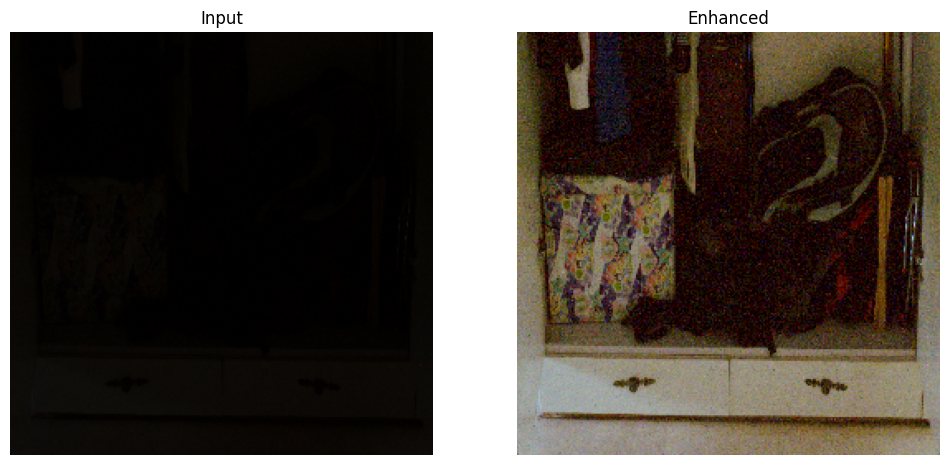

In [34]:
import matplotlib.pyplot as plt

inp = img[0].cpu().permute(
    1,2,0
).numpy()

out = enhanced[0].cpu().permute(
    1,2,0
).numpy()

fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(inp)
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(
    np.clip(out,0,1)
)
ax[1].set_title("Enhanced")
ax[1].axis("off")

plt.show()

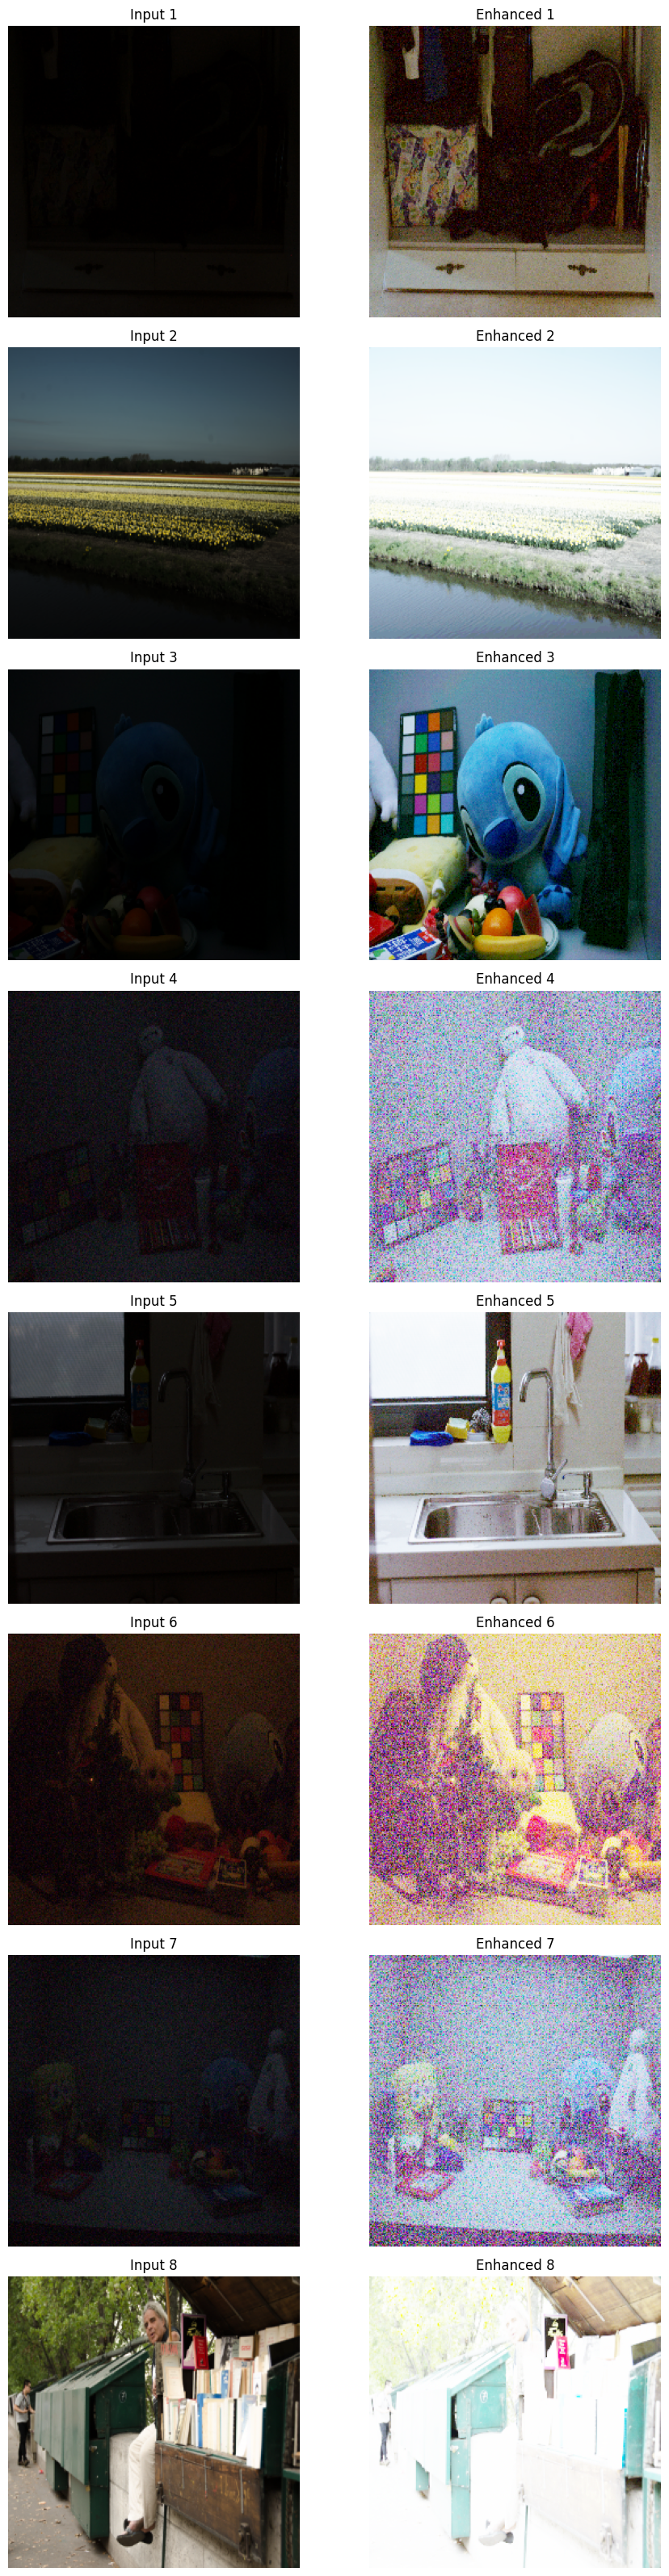

In [35]:
import matplotlib.pyplot as plt
import numpy as np

num_images = min(10, img.shape[0])

fig, ax = plt.subplots(
    num_images,
    2,
    figsize=(10, 4*num_images)
)

for i in range(num_images):

    inp = (
        img[i]
        .detach()
        .cpu()
        .permute(1,2,0)
        .numpy()
    )

    out = (
        enhanced[i]
        .detach()
        .cpu()
        .permute(1,2,0)
        .numpy()
    )

    ax[i,0].imshow(np.clip(inp,0,1))
    ax[i,0].set_title(f"Input {i+1}")
    ax[i,0].axis("off")

    ax[i,1].imshow(np.clip(out,0,1))
    ax[i,1].set_title(f"Enhanced {i+1}")
    ax[i,1].axis("off")

plt.tight_layout()
plt.show()

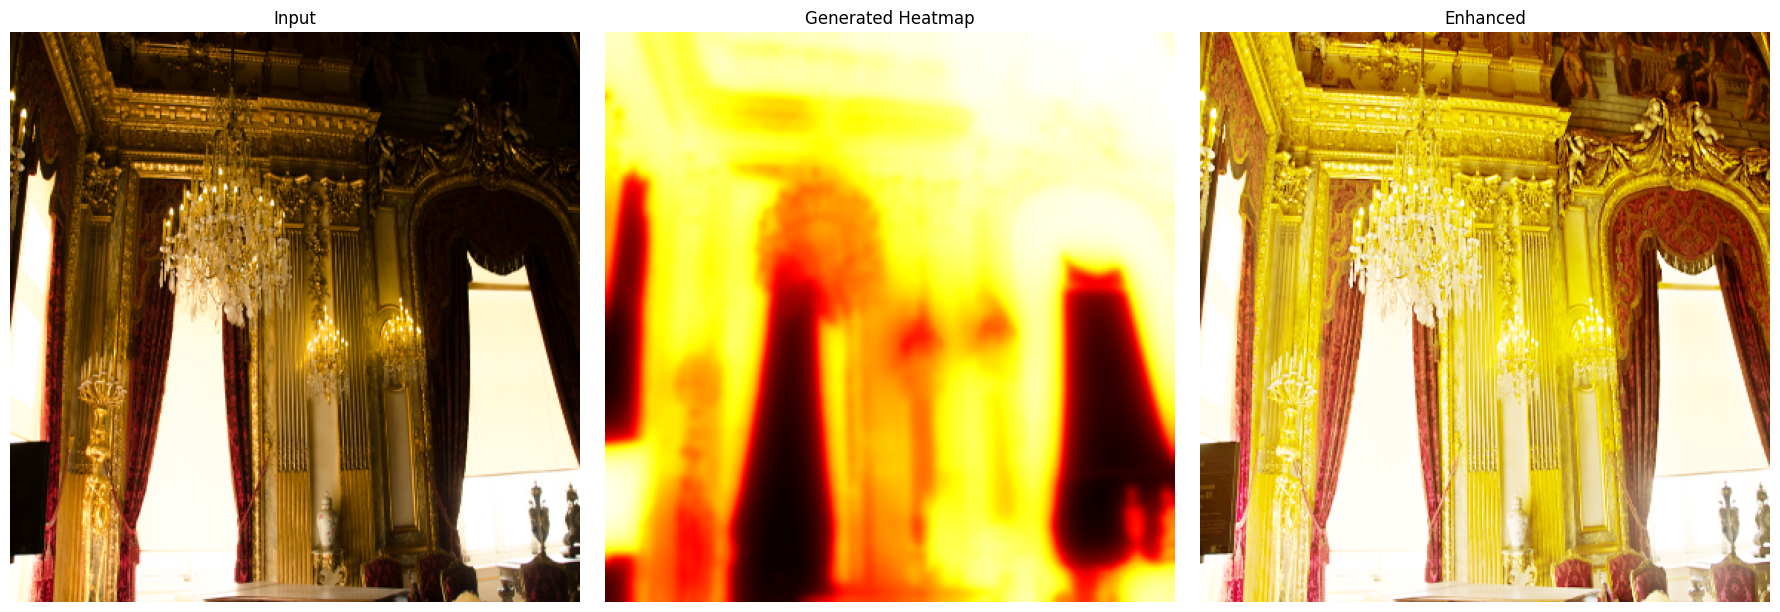

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load Image
# ==========================

img = cv2.imread("/kaggle/working/Merged/test/low/000104.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(np.float32) / 255.0

# ==========================
# Build Heatmap
# ==========================

gray = img.mean(axis=2)

# Multi-scale illumination estimate
blur1 = cv2.GaussianBlur(gray, (15,15), 0)
blur2 = cv2.GaussianBlur(gray, (51,51), 0)
blur3 = cv2.GaussianBlur(gray, (101,101), 0)

heatmap = (
    (1 - blur1) +
    (1 - blur2) +
    (1 - blur3)
) / 3

heatmap = np.clip(heatmap, 0, 1)

# ==========================
# Zero-DCE Style Enhancement
# ==========================

out = img.copy()

for i in range(8):

    strength = np.exp(-i/3)

    A = strength * heatmap

    A_rgb = np.stack(
        [A, A, A],
        axis=-1
    )

    out = (
        out
        + A_rgb * out * (1 - out)
    )

    out = np.clip(out, 0, 1)

# ==========================
# Visualize
# ==========================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(img)
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(heatmap, cmap="hot")
ax[1].set_title("Generated Heatmap")
ax[1].axis("off")

ax[2].imshow(out)
ax[2].set_title("Enhanced")
ax[2].axis("off")

plt.tight_layout()
plt.show()

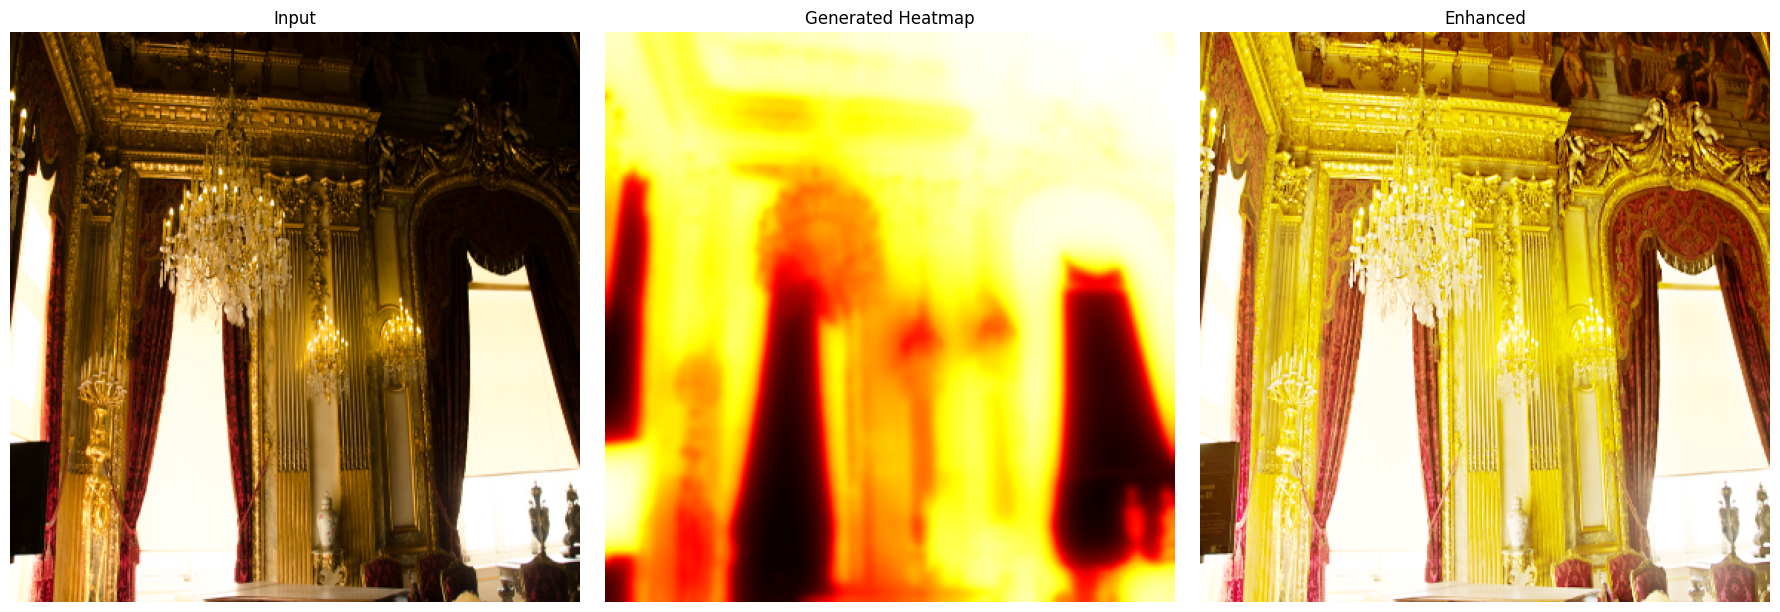

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load Image
# ==========================

img = cv2.imread("/kaggle/working/Merged/test/low/000104.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(np.float32) / 255.0

# ==========================
# Build Heatmap
# ==========================

gray = img.mean(axis=2)

# Multi-scale illumination estimate
blur1 = cv2.GaussianBlur(gray, (15,15), 0)
blur2 = cv2.GaussianBlur(gray, (51,51), 0)
blur3 = cv2.GaussianBlur(gray, (101,101), 0)

heatmap = (
    (1 - blur1) +
    (1 - blur2) +
    (1 - blur3)
) / 3

heatmap = np.clip(heatmap, 0, 1)

# ==========================
# Zero-DCE Style Enhancement
# ==========================

out = img.copy()

for i in range(8):

    strength = np.exp(-i/3)

    A = strength * heatmap

    A_rgb = np.stack(
        [A, A, A],
        axis=-1
    )

    out = (
        out
        + A_rgb * out * (1 - out)
    )

    out = np.clip(out, 0, 1)

# ==========================
# Visualize
# ==========================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(img)
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(heatmap, cmap="hot")
ax[1].set_title("Generated Heatmap")
ax[1].axis("off")

ax[2].imshow(out)
ax[2].set_title("Enhanced")
ax[2].axis("off")

plt.tight_layout()
plt.show()